## PROJECT TITLE:

### Digital Payment & Financial Inclusion in Africa

# CASE STUDY

Scope :

- Examines the adoption of digital payments across selected countries

- Focuses on the relationship between *internet penetration, GDP, and digital financial inclusion*.

Data Source :

- World Bank Open Data (Digital Payments, Internet Users, GDP).

Ojectives :

- Identify trends in digital payment adoption.

- Understand how digital infrastructure influences economic growth.

- Highlight emerging economies showing rapid adotion.

## EXECUTIVE SUMMARY

This project analyzes the adoption of digital payments across multiple countries using datasets from the World Bank. By examining key indicators; digital payments (% of population age 15+), internet penetration, and GDP.
This analysis identifies patterns and relationships that highlight the role of digital infrastructure in economic development.

The case study focuses on comparing emerging and developed economies, revealing that countries with higher internet penetration rates tend to adopt digital payments more rapidly. 
Additionally, the analysis shows that some emerging economies are accelerating in digital finance adoption, narrowing the gap with developed countries.

Through data cleaning, transformation, and visualization, the project presents clear insights into how financial technology adoption is intertwined with economic growth and inclusion. 
The findings are illustrated with professional line charts and comparative visualizations, providing a compelling narrative of the global digital payment landscape.

This project serves as both a data analytics portfolio piece and a foundation for scholarship applications, demonstrating the ability to combine technical skills with real-world economic insight.

## AUTHOR 

### *Damilola Aderemilekun Adegboye*

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
digital_file = r"C:\Users\JustDamad\Desktop\data_folder\WB_GS_G20_T_WIDEF.csv"
internet_file = r"C:\Users\JustDamad\Desktop\data_folder\WB_WDI_IT_NET_USER_ZS_WIDEF.csv"
gdp_file = r"C:\Users\JustDamad\Desktop\data_folder\WB_WDI_NY_GDP_MKTP_CD_WIDEF.csv"

In [3]:
## Let's load the data

digital = pd.read_csv(digital_file)
internet = pd.read_csv(internet_file)
gdp = pd.read_csv(gdp_file)

In [4]:
## Let's preview the data

print(digital.head())
print(internet.head())
print(gdp.head())

  FREQ FREQ_LABEL REF_AREA REF_AREA_LABEL    INDICATOR  \
0    A     Annual      AFG    Afghanistan  WB_GS_G20_T   
1    A     Annual      AFG    Afghanistan  WB_GS_G20_T   
2    A     Annual      AFG    Afghanistan  WB_GS_G20_T   
3    A     Annual      AGO         Angola  WB_GS_G20_T   
4    A     Annual      AGO         Angola  WB_GS_G20_T   

                                     INDICATOR_LABEL SEX SEX_LABEL  \
0  Made or received digital payments in the past ...   F    Female   
1  Made or received digital payments in the past ...   M      Male   
2  Made or received digital payments in the past ...  _T     Total   
3  Made or received digital payments in the past ...   F    Female   
4  Made or received digital payments in the past ...   M      Male   

  UNIT_MEASURE UNIT_MEASURE_LABEL  ... UNIT_MULT UNIT_MULT_LABEL  OBS_STATUS  \
0           PT         Percentage  ...         0           Units           A   
1           PT         Percentage  ...         0           Units      

In [5]:
## Since we want to do analysis on African Countries, let's filter fot African Countries

africa_countries = [
    "Nigeria", "Kenya", "Ghana", "South Africa", "Egypt", 
    "Morocco", "Uganda", "Tanzania", "Rwanda"
]

digital_africa = digital[digital["REF_AREA_LABEL"].isin(africa_countries)]
internet_africa = internet[internet["REF_AREA_LABEL"].isin(africa_countries)]
gdp_africa = gdp[gdp["REF_AREA_LABEL"].isin(africa_countries)]

In [6]:
# Let's List all columns that look like years

year_columns = [col for col in digital_africa.columns if col.isdigit()]
print(year_columns)

['2014', '2017', '2021', '2022']


In [7]:
digital_africa = digital_africa[["REF_AREA_LABEL", "2022"]].rename(columns = {"2022" : "Digital Payments"})
internet_africa = internet_africa[["REF_AREA_LABEL", "2022"]].rename(columns = {"2022" : "Internet Users"})
gdp_africa = gdp_africa[["REF_AREA_LABEL", "2022"]].rename(columns = {"2022" : "GDP per Capita"})

In [8]:
## Let's Strip spaces from column names

digital.columns = digital.columns.str.strip()
internet.columns = internet.columns.str.strip()
gdp.columns = gdp.columns.str.strip()

## Let's Filter for African countries

africa_countries = [
    "Nigeria", "Kenya", "Ghana", "South Africa", "Egypt",
    "Morocco", "Uganda", "Tanzania", "Rwanda"
]

digital_africa = digital[digital['REF_AREA_LABEL'].isin(africa_countries)]
internet_africa = internet[internet['REF_AREA_LABEL'].isin(africa_countries)]
gdp_africa = gdp[gdp['REF_AREA_LABEL'].isin(africa_countries)]

In [9]:
## Let's Identify most recent year column available

digital_years = [col for col in digital_africa.columns if col.isdigit()]
internet_years = [col for col in internet_africa.columns if col.isdigit()]
gdp_years = [col for col in gdp_africa.columns if col.isdigit()]

print("Digital Payments Years:", digital_years)
print("Internet Users Years:", internet_years)
print("GDP per Capita Years:", gdp_years)

Digital Payments Years: ['2014', '2017', '2021', '2022']
Internet Users Years: ['1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
GDP per Capita Years: ['1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']


In [10]:
## Let's Use the most recent year available

digital_latest_year = digital_years[-1]
internet_latest_year = internet_years[-1]
gdp_latest_year = gdp_years[-1]

In [11]:
## to get a better data, let's reduce it to Country and Latest Year

digital_latest = digital_africa[["REF_AREA_LABEL", digital_latest_year]].rename(columns = {digital_latest_year : "Digital Payments"})
internet_latest = internet_africa[["REF_AREA_LABEL", internet_latest_year]].rename(columns = {internet_latest_year : "Internet Users"})
gdp_latest = gdp_africa[["REF_AREA_LABEL", gdp_latest_year]].rename(columns = {gdp_latest_year: "GDP per Capita"})

In [12]:
## Because of the empty digital column, we might have duplicates
## Let's drop duplicates

digital_latest = digital_latest.drop_duplicates(subset = ["REF_AREA_LABEL"])
internet_latest = internet_latest.drop_duplicates(subset = ["REF_AREA_LABEL"])
gdp_latest = gdp_latest.drop_duplicates(subset = ["REF_AREA_LABEL"])

In [13]:
## Let's merge the DATASETS

df = digital_africa.merge(internet_africa, on = "REF_AREA_LABEL")
df = df.merge(gdp_africa, on = "REF_AREA_LABEL")

## Let's rename the columns for clarity

df = df.rename(columns = {"REF_AREA_LABEL" : "Country"})

df.head()

,FREQ_x,FREQ_LABEL_x,REF_AREA_x,Country,INDICATOR_x,INDICATOR_LABEL_x,SEX_x,SEX_LABEL_x,UNIT_MEASURE_x,UNIT_MEASURE_LABEL_x,...,2015_y,2016_y,2017,2018_y,2019_y,2020_y,2021,2022,2023_y,2024_y
0,A,Annual,GHA,Ghana,WB_GS_G20_T,Made or received digital payments in the past ...,F,Female,PT,Percentage,...,4.943681e+10,5.614418e+10,6.038541e+10,6.725935e+10,6.835263e+10,7.000824e+10,7.951420e+10,7.391900e+10,8.054715e+10,8.230811e+10
1,A,Annual,GHA,Ghana,WB_GS_G20_T,Made or received digital payments in the past ...,M,Male,PT,Percentage,...,4.943681e+10,5.614418e+10,6.038541e+10,6.725935e+10,6.835263e+10,7.000824e+10,7.951420e+10,7.391900e+10,8.054715e+10,8.230811e+10
2,A,Annual,GHA,Ghana,WB_GS_G20_T,Made or received digital payments in the past ...,_T,Total,PT,Percentage,...,4.943681e+10,5.614418e+10,6.038541e+10,6.725935e+10,6.835263e+10,7.000824e+10,7.951420e+10,7.391900e+10,8.054715e+10,8.230811e+10
3,A,Annual,KEN,Kenya,WB_GS_G20_T,Made or received digital payments in the past ...,F,Female,PT,Percentage,...,7.012045e+10,7.481514e+10,8.203651e+10,9.220298e+10,1.003784e+11,1.006575e+11,1.097037e+11,1.144490e+11,1.075009e+11,1.203396e+11
4,A,Annual,KEN,Kenya,WB_GS_G20_T,Made or received digital payments in the past ...,M,Male,PT,Percentage,...,7.012045e+10,7.481514e+10,8.203651e+10,9.220298e+10,1.003784e+11,1.006575e+11,1.097037e+11,1.144490e+11,1.075009e+11,1.203396e+11


In [14]:
# See exactly how pandas sees the column names
print(df.columns.tolist())

['FREQ_x', 'FREQ_LABEL_x', 'REF_AREA_x', 'Country', 'INDICATOR_x', 'INDICATOR_LABEL_x', 'SEX_x', 'SEX_LABEL_x', 'UNIT_MEASURE_x', 'UNIT_MEASURE_LABEL_x', 'DATABASE_ID_x', 'DATABASE_ID_LABEL_x', 'UNIT_MULT_x', 'UNIT_MULT_LABEL_x', 'OBS_STATUS_x', 'OBS_STATUS_LABEL_x', 'OBS_CONF_x', 'OBS_CONF_LABEL_x', '2014_x', '2017_x', '2021_x', '2022_x', 'STRUCTURE_x', 'STRUCTURE_ID_x', 'ACTION_x', 'FREQ_y', 'REF_AREA_y', 'INDICATOR_y', 'SEX_y', 'AGE_x', 'URBANISATION_x', 'UNIT_MEASURE_y', 'COMP_BREAKDOWN_1_x', 'COMP_BREAKDOWN_2_x', 'COMP_BREAKDOWN_3_x', 'AGG_METHOD_x', 'UNIT_TYPE_x', 'DECIMALS_x', 'DATABASE_ID_y', 'TIME_FORMAT_x', 'COMMENT_TS_x', 'UNIT_MULT_y', 'DATA_SOURCE_x', 'OBS_CONF_y', 'OBS_STATUS_y', 'FREQ_LABEL_y', 'INDICATOR_LABEL_y', 'SEX_LABEL_y', 'AGE_LABEL_x', 'URBANISATION_LABEL_x', 'UNIT_MEASURE_LABEL_y', 'COMP_BREAKDOWN_1_LABEL_x', 'COMP_BREAKDOWN_2_LABEL_x', 'COMP_BREAKDOWN_3_LABEL_x', 'AGG_METHOD_LABEL_x', 'UNIT_TYPE_LABEL_x', 'DECIMALS_LABEL_x', 'DATABASE_ID_LABEL_y', 'TIME_FORMAT

In [15]:
## Strip spaces first
## To get the latest year column

digital.columns = digital.columns.str.strip()
internet.columns = internet.columns.str.strip()
gdp.columns = gdp.columns.str.strip()

country_col = 'REF_AREA_LABEL'

def latest_year_col(df):
    year_cols = [col for col in df.columns if col.isdigit() or (col.endswith('_y') and col.split('_')[0].isdigit())]
    def col_year(c):
        return int(c.split('_')[0]) if '_' in c else int(c)
    return sorted(year_cols, key=col_year)[-1]

In [16]:
## Let's get the latest columns

digital_col = latest_year_col(digital)
internet_col = latest_year_col(internet)
gdp_col = latest_year_col(gdp)

print("Using columns:", digital_col, internet_col, gdp_col)

Using columns: 2022 2024 2024


In [17]:
## Let's extract needed data

digital_latest = digital[[country_col, digital_col]].rename(columns={
    country_col: 'Country',
    digital_col: 'Digital Payments'
})

internet_latest = internet[[country_col, internet_col]].rename(columns={
    country_col: 'Country',
    internet_col: 'Internet Users'
})

gdp_latest = gdp[[country_col, gdp_col]].rename(columns={
    country_col: 'Country',
    gdp_col: 'GDP per Capita'
})

In [18]:
## Let's remove duplicates and merge 

digital_latest = digital_latest.drop_duplicates(subset='Country')
internet_latest = internet_latest.drop_duplicates(subset='Country')
gdp_latest = gdp_latest.drop_duplicates(subset='Country')

df_final = digital_latest.merge(internet_latest, on='Country')
df_final = df_final.merge(gdp_latest, on='Country')

print(df_final.head())

                Country  Digital Payments  Internet Users  GDP per Capita
0           Afghanistan               NaN             NaN             NaN
1                Angola               NaN             NaN    1.009989e+11
2               Albania               NaN             NaN    2.704643e+10
3  United Arab Emirates               NaN        100.0000    5.523248e+11
4             Argentina               NaN         89.6672    6.383655e+11


In [19]:
## Let's show omly African countries

africa_countries = [
    "Nigeria", "Kenya", "Ghana", "South Africa", "Egypt",
    "Morocco", "Uganda", "Tanzania", "Rwanda"
]
digital = digital[digital["REF_AREA_LABEL"].isin(africa_countries)]
internet = internet[internet["REF_AREA_LABEL"].isin(africa_countries)]
gdp = gdp[gdp["REF_AREA_LABEL"].isin(africa_countries)]

In [20]:
digital = digital.groupby("REF_AREA_LABEL").last().reset_index()
internet = internet.groupby("REF_AREA_LABEL").last().reset_index()
gdp = gdp.groupby("REF_AREA_LABEL").last().reset_index()

In [21]:
year = '2022'

In [22]:
digital_latest = digital[['REF_AREA_LABEL', year]].rename(columns={year:'Digital Payments'})
internet_latest = internet[['REF_AREA_LABEL', year]].rename(columns={year:'Internet Users'})
gdp_latest = gdp[['REF_AREA_LABEL', year]].rename(columns={year:'GDP per Capita'})

In [23]:
df_final = digital_latest.merge(internet_latest, on='REF_AREA_LABEL', how='inner')
df_final = df_final.merge(gdp_latest, on='REF_AREA_LABEL', how='inner')

In [24]:
## Let's drop any remaining NaN

df_final = df_final.dropna()

In [25]:
print(df_final)

Empty DataFrame
Columns: [REF_AREA_LABEL, Digital Payments, Internet Users, GDP per Capita]
Index: []


In [26]:
print(digital["REF_AREA_LABEL"].unique())
print(internet["REF_AREA_LABEL"].unique())
print(gdp["REF_AREA_LABEL"].unique())

['Ghana' 'Kenya' 'Morocco' 'Nigeria' 'Rwanda' 'South Africa' 'Tanzania'
 'Uganda']
['Ghana' 'Kenya' 'Morocco' 'Nigeria' 'Rwanda' 'South Africa' 'Tanzania'
 'Uganda']
['Ghana' 'Kenya' 'Morocco' 'Nigeria' 'Rwanda' 'South Africa' 'Tanzania'
 'Uganda']


In [27]:
print(digital.columns)
print(internet.columns)
print(gdp.columns)

Index(['REF_AREA_LABEL', 'FREQ', 'FREQ_LABEL', 'REF_AREA', 'INDICATOR',
       'INDICATOR_LABEL', 'SEX', 'SEX_LABEL', 'UNIT_MEASURE',
       'UNIT_MEASURE_LABEL', 'DATABASE_ID', 'DATABASE_ID_LABEL', 'UNIT_MULT',
       'UNIT_MULT_LABEL', 'OBS_STATUS', 'OBS_STATUS_LABEL', 'OBS_CONF',
       'OBS_CONF_LABEL', '2014', '2017', '2021', '2022'],
      dtype='object')
Index(['REF_AREA_LABEL', 'STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ',
       'REF_AREA', 'INDICATOR', 'SEX', 'AGE', 'URBANISATION', 'UNIT_MEASURE',
       'COMP_BREAKDOWN_1', 'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_3',
       'AGG_METHOD', 'UNIT_TYPE', 'DECIMALS', 'DATABASE_ID', 'TIME_FORMAT',
       'COMMENT_TS', 'UNIT_MULT', 'DATA_SOURCE', 'OBS_CONF', 'OBS_STATUS',
       'FREQ_LABEL', 'INDICATOR_LABEL', 'SEX_LABEL', 'AGE_LABEL',
       'URBANISATION_LABEL', 'UNIT_MEASURE_LABEL', 'COMP_BREAKDOWN_1_LABEL',
       'COMP_BREAKDOWN_2_LABEL', 'COMP_BREAKDOWN_3_LABEL', 'AGG_METHOD_LABEL',
       'UNIT_TYPE_LABEL', 'DECIMALS_LABEL', 'D

In [28]:
## Let's Select correct columns

digital_latest = digital[['REF_AREA_LABEL', '2022']].rename(columns={
    'REF_AREA_LABEL': 'Country',
    '2022': 'Digital Payments'
})

internet_latest = internet[['REF_AREA_LABEL', '2022']].rename(columns={
    'REF_AREA_LABEL': 'Country',
    '2022': 'Internet Users'
})

gdp_latest = gdp[['REF_AREA_LABEL', '2022']].rename(columns={
    'REF_AREA_LABEL': 'Country',
    '2022': 'GDP per Capita'
})

In [29]:
## Let's Remove duplicates & Merge using INNER JOIN

digital_latest = digital_latest.drop_duplicates(subset='Country')
internet_latest = internet_latest.drop_duplicates(subset='Country')
gdp_latest = gdp_latest.drop_duplicates(subset='Country')

df_final = digital_latest.merge(internet_latest, on='Country', how='inner')
df_final = df_final.merge(gdp_latest, on='Country', how='inner')

In [30]:
## Let's Drop missing values

df_final = df_final.dropna()

print(df_final)

Empty DataFrame
Columns: [Country, Digital Payments, Internet Users, GDP per Capita]
Index: []


In [31]:
print(digital[['REF_AREA_LABEL', '2022']])
print(internet[['REF_AREA_LABEL', '2022']])
print(gdp[['REF_AREA_LABEL', '2022']])

  REF_AREA_LABEL  2022
0          Ghana   NaN
1          Kenya   NaN
2        Morocco   NaN
3        Nigeria   NaN
4         Rwanda   NaN
5   South Africa   NaN
6       Tanzania   NaN
7         Uganda   NaN
  REF_AREA_LABEL     2022
0          Ghana  69.3607
1          Kenya      NaN
2        Morocco  89.9000
3        Nigeria  37.6975
4         Rwanda  31.2252
5   South Africa  75.4556
6       Tanzania  22.1010
7         Uganda  11.1246
  REF_AREA_LABEL          2022
0          Ghana  7.391900e+10
1          Kenya  1.144490e+11
2        Morocco  1.312453e+11
3        Nigeria  6.469503e+11
4         Rwanda  1.331616e+10
5   South Africa  4.075960e+11
6       Tanzania  7.574912e+10
7         Uganda  4.556533e+10


In [32]:
## Let's check the year that has data

digital[['2014','2017','2021','2022']]

,2014,2017,2021,2022
0,25.60,49.47,65.57,NaN
1,69.44,78.96,77.56,NaN
2,NaN,16.71,30.30,NaN
3,37.02,29.66,33.74,NaN
4,27.99,38.92,NaN,NaN
5,65.99,60.11,80.81,NaN
6,35.54,42.99,50.22,NaN
7,40.47,54.69,62.58,NaN


In [33]:
## Since year 2017 has complete data, we'll make use of that..

year = "2017"

digital_latest = digital[["REF_AREA_LABEL", year]].rename(columns = {
    "REF_AREA_LABEL" : "Country",
    year : "Digital Payments"
})

internet_latest = internet[["REF_AREA_LABEL", year]].rename(columns = {
    "REF_AREA_LABEL" : "Country",
    year : "Internet Users"
})

gdp_latest = gdp[["REF_AREA_LABEL", year]].rename(columns = {
    "REF_AREA_LABEL" : "Country",
    year : "GDP per Capita"
})

In [34]:
## Let's merge and clean the Dataset

df_final = digital_latest.merge(internet_latest, on = "Country", how = "inner")
df_final = df_final.merge(gdp_latest, on = "Country", how = "inner")

df_final = df_final.dropna()

print(df_final)

        Country  Digital Payments  Internet Users  GDP per Capita
0         Ghana             49.47         37.8842    6.038541e+10
1         Kenya             78.96         17.8271    8.203651e+10
2       Morocco             16.71         61.7622    1.185406e+11
3       Nigeria             29.66         25.9000    3.757457e+11
4        Rwanda             38.92         17.2000    9.252834e+09
5  South Africa             60.11         56.1674    3.814488e+11
6      Tanzania             42.99         14.4634    5.327488e+10


In [35]:
!pip install wbgapi pandas


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
import wbgapi as wb
import pandas as pd

C:\Users\JustDamad\AppData\Local\Programs\Python\Python314\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [37]:
countries = ["NGA", "GHA", "KEN", "MAR", "RWA"]
years = range(2010, 2023)

In [38]:
import requests
import pandas as pd

## Let's fetch and clean data

def fetch_wb_data(indicator):
    url = f"https://api.worldbank.org/v2/country/NGA;GHA;KEN;MAR;RWA/indicator/{indicator}?format=json&per_page=1000"
    
    response = requests.get(url)
    data = response.json()
    
    df = pd.json_normalize(data[1])
    
    df = df[['country.value', 'date', 'value']]
    return df

## Let's Fetch datasets

gdp = fetch_wb_data('NY.GDP.MKTP.CD')
internet = fetch_wb_data('IT.NET.USER.ZS')

## Let's Rename columns

gdp.columns = ['Country', 'Year', 'GDP']
internet.columns = ['Country', 'Year', 'Internet_Users']

## Let's Merge

data = pd.merge(gdp, internet, on=['Country', 'Year'])

## Now we can  Clean the Data

data['Year'] = data['Year'].astype(int)
data = data.dropna()

data.head()

,Country,Year,GDP,Internet_Users
2,Ghana,2023,8.054715e+10,69.9445
3,Ghana,2022,7.391900e+10,69.3607
4,Ghana,2021,7.951420e+10,68.6000
5,Ghana,2020,7.000824e+10,62.5176
6,Ghana,2019,6.835263e+10,22.0732


## VISUALIZATION

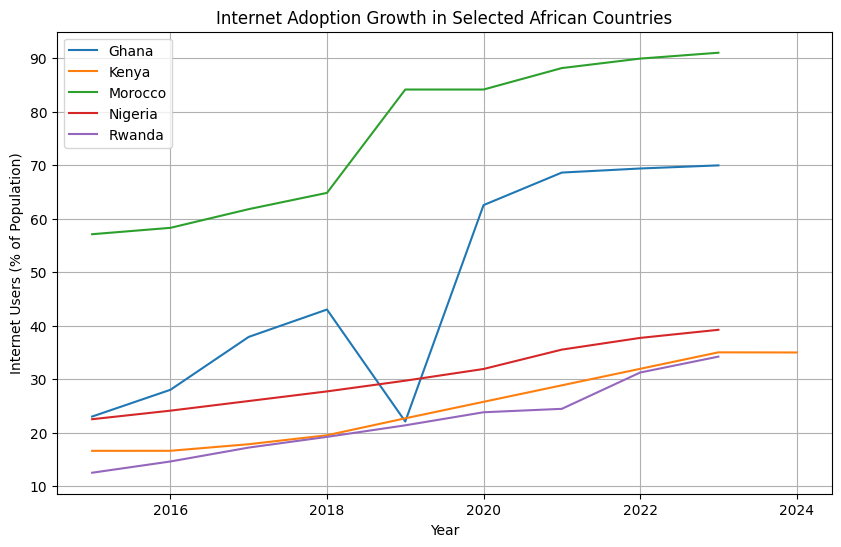

In [39]:
import matplotlib.pyplot as plt

## Let's Filter recent years for clarity


df = data[data['Year'] >= 2015]

## Let's  Plot

plt.figure(figsize=(10,6))

for country in df['Country'].unique():
    subset = df[df['Country'] == country]
    plt.plot(subset['Year'], subset['Internet_Users'], label=country)

plt.title("Internet Adoption Growth in Selected African Countries")
plt.xlabel("Year")
plt.ylabel("Internet Users (% of Population)")
plt.legend()
plt.grid()

plt.show()

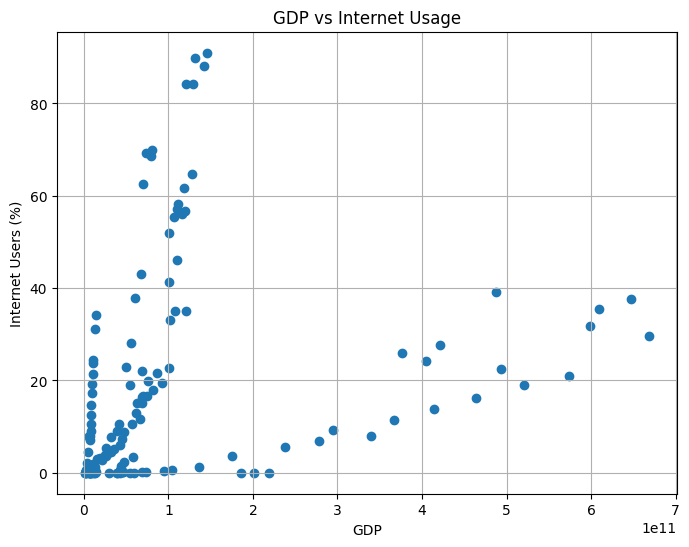

In [40]:
## GDP vs Internet scatter

plt.figure(figsize=(8,6))

plt.scatter(data['GDP'], data['Internet_Users'])

plt.title("GDP vs Internet Usage")
plt.xlabel("GDP")
plt.ylabel("Internet Users (%)")

plt.grid()
plt.show()

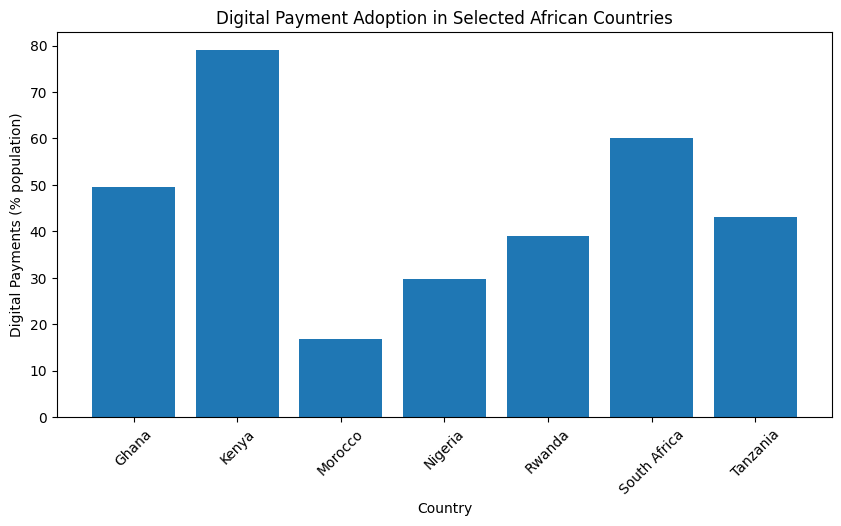

In [41]:
## Let's plot a Bar Chart

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(df_final['Country'], df_final['Digital Payments'])
plt.title("Digital Payment Adoption in Selected African Countries")
plt.xlabel("Country")
plt.ylabel("Digital Payments (% population)")
plt.xticks(rotation=45)
plt.show()

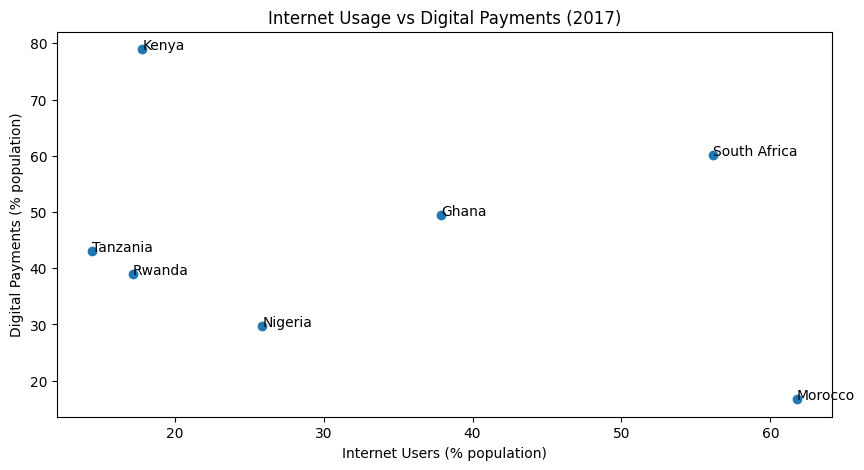

In [42]:
## Let's plot a Scatter Plot
## add country labels

plt.figure(figsize = (10,5))
plt.scatter(df_final["Internet Users"] , df_final["Digital Payments"])

for i in range(len(df_final)):
    plt.text(df_final["Internet Users"][i], df_final["Digital Payments"][i], df_final["Country"][i])

plt.title("Internet Usage vs Digital Payments (2017)")
plt.xlabel("Internet Users (% population)")
plt.ylabel("Digital Payments (% population)")
plt.show()

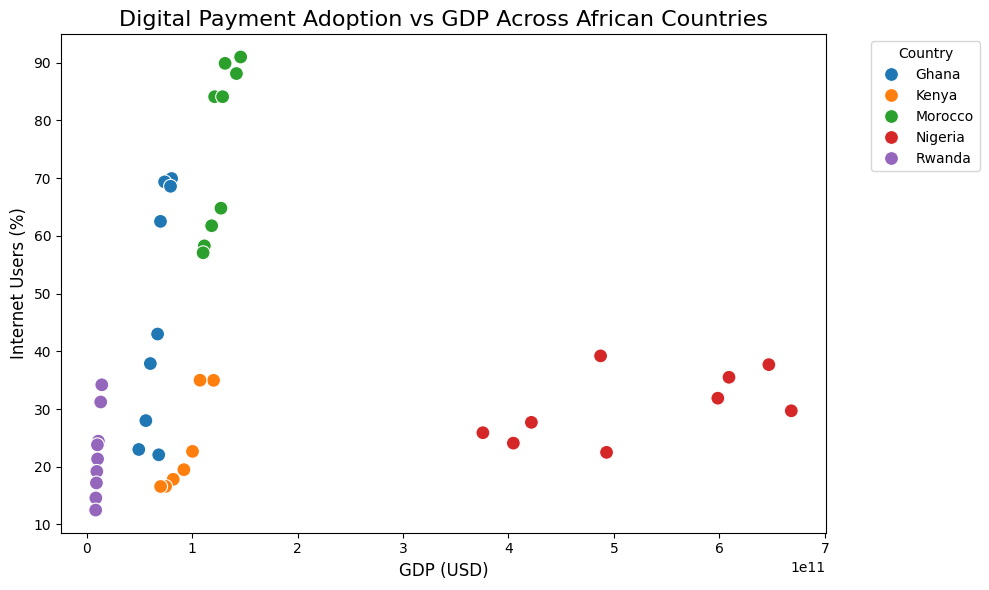

In [43]:
## Let's Save chart as PNG 

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='GDP', y='Internet_Users', hue='Country', s=100)
plt.title("Digital Payment Adoption vs GDP Across African Countries", fontsize=16)
plt.xlabel("GDP (USD)", fontsize=12)
plt.ylabel("Internet Users (%)", fontsize=12)
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()


plt.savefig("digital_payments_chart.png", dpi=300)  # high-quality PNG
plt.show()

## KEY FINDINGS :

* Digital payment addoption in African Countries shows a strong relationship with internet access, but a weaker relationship with GDP.

## INTERPRETATION :

* Countries with *higher internet penetration* tend to have *higher digital payment usage*

* However, *wealth* (GDP) alone does not guarantee digital adoption

* This suggests that:

   - Digital infrastructure matters more than economic size

## CONCLUSION

 * My analysis revealed that digital payment adoption in African economies is more strongly influenced by internet accessibility than by GDP levels, highlighting the critical role of digital infrastructure in driving financial inclusion.

## SIGNED.

* FinTech Data Analyst.

 # *Damilola .A. Adegboye*